# Демографический анализ — Светлана

## Загрузка обработанных данных

_Загрузить чистый датасет из ноутбука «01. Обработка данных»._

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("NetflixShows_clear.csv")
df.head(2)

,Unnamed: 0,index,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,type,audience_segment,genre,country,imdbRating,imdbVotes,rated
0,0,0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.0,80,"crude and sexual humor, language and some drug...",movie,Teens,"Comedy, Crime",United States,5.9,"190,250",PG-13
1,1,1,Lucky Number Slevin,R,Restricted. May be inappropriate for children ...,2006,NaN,82,"strong violence, sexual content and adult lang...",movie,Adults,"Crime, Drama, Thriller","United Kingdom, Germany, Canada, United States",7.7,"337,898",R


## Анализ коммерческого потенциала развлекательного контента и международных рынков на основе данных Netflix

### Задачи проекта
 - провести анализ аудитории и характеристик контента;<br>
 - определить ключевые типы контента и их целевую аудиторию;<br>
 - выполнить анализ демографических и региональных особенностей рынков;<br>
 - оценить коммерческую привлекательность различных стран и регионов;<br>
 - сформировать показатели рыночного потенциала;<br>
 - определить приоритетные рынки для продвижения и монетизации контента;<br>


### Часть 1. Анализ аудитории
На данном этапе выполняется анализ распределения аудитории по рейтинговым категориям контента. Для каждой группы рейтингов рассчитывается суммарное количество пользователей, после чего данные сортируются и визуализируются в виде столбчатой диаграммы. Это позволяет определить, какие типы контента имеют наибольший пользовательский охват и потенциальную массовую привлекательность.

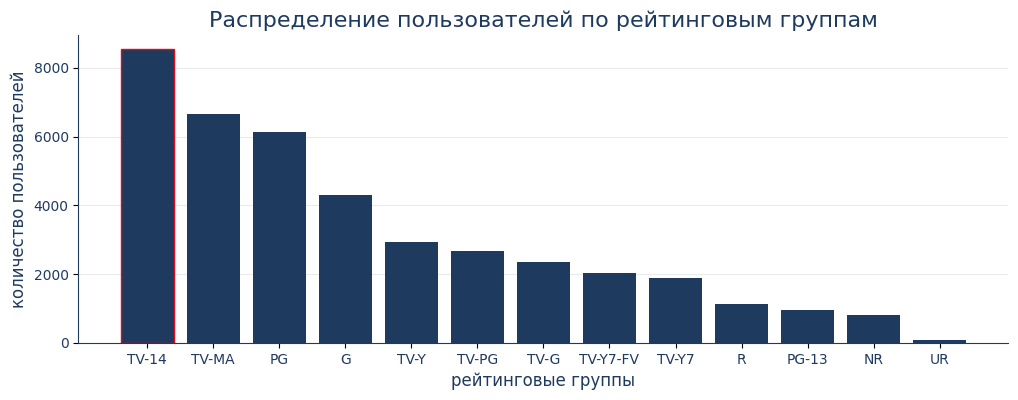

In [244]:
users = df.pivot_table(index = 'rating',values = 'user rating size',aggfunc='sum')
users_sorted = users.sort_values(by='user rating size', ascending=False)

plt.figure(figsize = (12,4))
bars = plt.bar(users_sorted.index, users_sorted['user rating size'], color ='#1f3a5f')

plt.title('Распределение пользователей по рейтинговым группам', fontsize = 16, color ='#1f3a5f' )
plt.xlabel ('рейтинговые группы',fontsize = 12, color ='#1f3a5f')
plt.ylabel ('количество пользователей',fontsize = 12, color ='#1f3a5f')
plt.yticks (range(0,8500, 2000), color ='#1f3a5f')
plt.xticks (color ='#1f3a5f')
plt.grid(axis='y', color='#1f3a5f', alpha=0.1)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#1f3a5f')
ax.spines['bottom'].set_color('#1f3a5f')
bars[0].set_edgecolor('#E50914')
bars[0].set_linewidth(1)

Вывод: Анализ распределения пользователей по рейтинговым категориям показывает, что наибольшей популярностью пользуется контент с рейтингом TV-14 (Parents strongly cautioned. May be unsuitable for children ages 14 and under.). Также значительное количество пользователей приходится на категории TV-MA (For mature audiences.  May not be suitable for children 17 and under.) и PG (Parental guidance suggested. May not be suitable for children.). В то же время узкоспециализированный контент (например, PG-13 и bloody war violence, language throughout and some sexual material.) привлекает значительно меньшее количество пользователей. 
Есть стабильный паттерн для G, TV-G, TV-Y, TV-Y7, TV-Y7-FV (Suitable for children ages 7 and older). 
Это свидетельствует о том, что основная аудитория платформы ориентирована на подростковый и взрослый контент.
UR и NR This movie has not been rated - здесь стоит далее проанализировать причины почему контент, находящийся под этой категорией никак не классифицирован, возможно ошибка данных.

Выполняем анализ распределения аудитории по возрастным категориям. Для каждой группы рассчитываем суммарный размер аудитории и её доля в общей структуре пользователей. Полученные результаты позволяют определить, какие возрастные сегменты обладают наибольшим пользовательским охватом и потенциальной коммерческой привлекательностью.

In [245]:
audience = df.pivot_table(index = 'audience_segment',values = 'user rating size',aggfunc='sum').sort_values(by='user rating size', ascending=False)

audience = audience.drop(index = 'Unrated').reset_index()
audience['pct_rating size'] = round(audience['user rating size'] / sum(audience['user rating size']),2)

audience

,audience_segment,user rating size,pct_rating size
0,Kids,13508,0.34
1,Teens,9504,0.24
2,Family,8798,0.22
3,Adults,7778,0.20


По результатам анализа можно сделать вывод, что наибольшую долю аудитории составляет детский сегмент (0–12 лет), на который приходится около 34% пользователей. Подростковая аудитория (13–17 лет) занимает около 24%, тогда как взрослая аудитория (18+) составляет примерно 22%. Семейная аудитория поддерживает тренды по детскому и подростковому еонтенту.

Полученные результаты показывают, что контент, ориентированный на детскую и подростковую аудиторию, обладает наибольшим потенциалом массового охвата и может представлять повышенный интерес с точки зрения масштабирования, продвижения и лицензирования. В то же время взрослый контент, несмотря на меньшую долю аудитории, может иметь более высокую ценность в премиальных и нишевых сегментах рынка.

### Часть 2. Характеристики контента

Определяем позиционирование контента по аудитории и оценке его коммерческого потенциала для различных рынков и возрастных групп.

Для анализа контента создаем таблицу соответствия возрастных рейтингов Netflix и целевых аудиторий. Для каждого рейтинга определяем три показателя: Kids Audience Fit, Youth Audience Fit и Adult Audience Fit.

Каждому рейтингу присваиваем коэффициенты от 0 до 1, отражающие его привлекательность для соответствующей аудитории. Например, рейтинги G/TV-G получают высокий Kids Audience Fit (1), PG-13 и TV-14 — высокий Youth Audience Fit, а R и TV-MA — высокий Adult Audience Fit.

Коэффициенты задаются "экспертно" на основе возрастных ограничений Netflix и используются для преобразования категориальных рейтингов в числовые показатели, которые затем применяются при анализе контента и соответствия контента аудитории (Audience Fit).

In [246]:
content_feature = pd.DataFrame({
    'rating':   ['G','TV-G','TV-Y','TV-Y7','TV-Y7-FV',
                'PG','TV-PG',
                'PG-13','TV-14',
                'R','TV-MA','NR','UR'],

    'audience_segment': ['Kids','Kids','Kids','Kids','Kids',
                'Family','Family',
                'Teens','Teens',
                'Adults','Adults','Adults','Adults'],

    'kids_audience_fit': [1.0,1.0,1.0,1.0,1.0,
                    0.7,0.7,
                    0.2,0.2,
                    0.0,0.0,0.0,0.0],

    'youth_audience_fit': [0.2,0.2,0.2,0.2,0.2,
                    0.7,0.7,
                    1.0,1.0,
                    0.4,0.4,0.4,0.4],

    'adult_audience_fit': [0.2,0.2,0.2,0.2,0.2,
                    0.4,0.4,
                    0.6,0.6,
                    1.0,1.0,1.0,1.0]})
content_feature = content_feature.drop(columns = 'audience_segment')
content = df.merge(content_feature,on='rating',how='left').reset_index()
content.head(2)

,level_0,Unnamed: 0,index,title,rating,ratingLevel,release year,user rating score,user rating size,sceneDesc,type,audience_segment,genre,country,imdbRating,imdbVotes,rated,kids_audience_fit,youth_audience_fit,adult_audience_fit
0,0,0,0,White Chicks,PG-13,Parents strongly cautioned. May be inappropria...,2004,82.0,80,"crude and sexual humor, language and some drug...",movie,Teens,"Comedy, Crime",United States,5.9,"190,250",PG-13,0.2,1.0,0.6
1,1,1,1,Lucky Number Slevin,R,Restricted. May be inappropriate for children ...,2006,NaN,82,"strong violence, sexual content and adult lang...",movie,Adults,"Crime, Drama, Thriller","United Kingdom, Germany, Canada, United States",7.7,"337,898",R,0.0,0.4,1.0


### Часть 3. Анализ рынков
Выполняем оценку международных рынков через сочетание демографического потенциала и экономической привлекательности, включая размер аудитории, возрастную структуру населения, уровень доходов.

In [247]:
#формирование демографического профиля стран
population = pd.read_excel('UN_Population_2023.xlsx')
gdp = pd.read_excel('WB_gdp_2023.xlsx')
geo = pd.read_excel('Georgaphy data.xlsx')
income_rate = pd.read_csv('lifeexpectancy-verbose.csv')

gdp = gdp[['country_code','gdp_per_capita_usd']]

youth_audience = ['20-24','25-29','30-34']

adult_columns = ['20-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80-84','85-89','90-94']
population['0-12'] = round((population['0-4']+population['5-9']+population['10-14']/5*3),0)
population['13-17'] = round((population['10-14']/5*2 + population['15-19']/5*3),0)
population['18+'] = round((population['15-19']/5*2+population[adult_columns].sum(axis=1)),0)
population['young_adults'] = round((population[youth_audience].sum(axis=1) + population['15-19']/5*2),0)
population['total_population'] = population['0-12']+population['13-17']+population['18+']

population = population[population['total_population'] > 0]
population['0-12_%'] = np.where(population['total_population'] == 0,0,round(population['0-12']/population['total_population'],2))
population['13-17_%'] = np.where(population['total_population'] == 0,0,round(population['13-17']/population['total_population'],2))
population['18+_%'] = np.where(population['total_population'] == 0,0, round(population['18+']/population['total_population'],2))
population['young_adults_%'] = np.where(population['total_population'] == 0,0, round(population['young_adults']/population['total_population'],2))

population = population[['Region, subregion, country or area *', 'ISO3 Alpha-code', '0-12', '13-17', 'young_adults', '18+', 'total_population', '0-12_%', '13-17_%', 'young_adults_%', '18+_%']]
population = population.rename(columns={
                        'Region, subregion, country or area *': 'country',
                        'ISO3 Alpha-code': 'country_code',
                        '0-12': 'age_group_0-12',
                        '13-17': 'age_group_13-17',
                        '18+': 'age_group_18+'})

population.head(1)

,country,country_code,age_group_0-12,age_group_13-17,young_adults,age_group_18+,total_population,0-12_%,13-17_%,young_adults_%,18+_%
0,Burundi,BDI,5432.0,1698.0,3531.0,6559.0,13689.0,0.4,0.12,0.26,0.48


In [248]:
#формирование категорий дохода стран
income_rate = income_rate[['CountryCode', 'WorldBankIncomeGroupDisplay']]
income_rate = income_rate.rename(columns = {'WorldBankIncomeGroupDisplay': 'income_category', 'CountryCode': 'country_code'})
income_rate = income_rate.drop_duplicates(subset='country_code')
income_rate.head(1)

,country_code,income_category
0,NIC,Lower_middle_income


In [249]:
#формирование региональной классификации стран
geo = geo[['alpha-3', 'region','sub-region']]
geo = geo.rename(columns = {'alpha-3': 'country_code'})
geo.head(1)

,country_code,region,sub-region
0,AFG,Asia,Southern Asia


In [250]:
#формирование итогового датасета рынков
regions= pd.merge(population, geo, on='country_code', how = 'left' ).merge(income_rate,on='country_code',how = 'left').merge(gdp, on ='country_code',how = 'left')
regions = regions.dropna(subset=['region', 'gdp_per_capita_usd'])
#заполнение пропусков в income_category модальным значением по субрегиону
moda = regions.groupby('sub-region')['income_category'].apply(lambda x: x.mode()[0])
regions['income_category'] = regions['income_category'].fillna(regions['sub-region'].map(moda))

regions.head(3)

,country,country_code,age_group_0-12,age_group_13-17,young_adults,age_group_18+,total_population,0-12_%,13-17_%,young_adults_%,18+_%,region,sub-region,income_category,gdp_per_capita_usd
0,Burundi,BDI,5432.0,1698.0,3531.0,6559.0,13689.0,0.40,0.12,0.26,0.48,Africa,Sub-Saharan Africa,Low_income,250.627253
1,Comoros,COM,279.0,90.0,231.0,481.0,850.0,0.33,0.11,0.27,0.57,Africa,Sub-Saharan Africa,Low_income,1560.273785
2,Djibouti,DJI,296.0,115.0,346.0,742.0,1153.0,0.26,0.10,0.30,0.64,Africa,Sub-Saharan Africa,Low_income,3381.297797


Выполняем анализ распределения населения стран. Для корректного сравнения стран с сильно различающейся численностью населения используется логарифмическое преобразование данных. Построенная гистограмма позволяет оценить структуру мировых рынков и определить, какая часть стран относится к крупным, средним или малым по размеру населения рынкам.

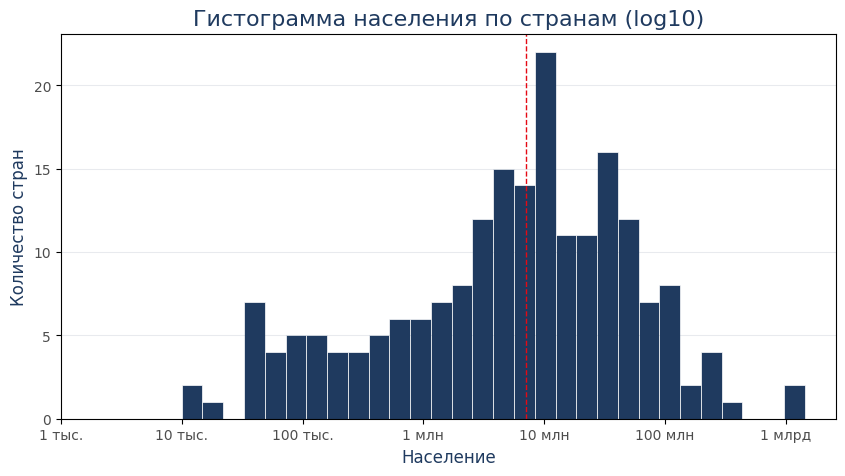

In [251]:
pop = regions['total_population']

#население стран имеет большой разброс значений, поэтому призводим логарифмирование численности населения
log_population = np.log10(pop)

plt.figure(figsize=(10,5))

plt.hist(log_population, bins=30, color='#1f3a5f', edgecolor='white', linewidth=0.5)

plt.title('Гистограмма населения по странам (log10)', fontsize=16, color='#1f3a5f')
plt.xlabel('Население', fontsize=12, color='#1f3a5f')
plt.ylabel('Количество стран', fontsize=12, color='#1f3a5f')

xticks = [0, 1, 2, 3, 4, 5, 6]
xtick_labels = ['1 тыс.', '10 тыс.', '100 тыс.', '1 млн', '10 млн', '100 млн', '1 млрд']

plt.xticks(xticks, xtick_labels, color='#4d4d4d')
plt.yticks(color='#4d4d4d')

plt.grid(axis='y', alpha=0.1, color='#1f3a5f')

median = log_population.median()
plt.axvline(median, color='#E50914', linestyle='--', linewidth=1)
plt.show()

Гистограмма показывает, что распределение населения по странам является сильно асимметричным: большинство стран имеют относительно небольшое или среднее население, в то время как лишь ограниченное количество стран формируют категорию сверхкрупных рынков. Медианное значение находится на уровне около 10 млн человек, что означает, что половина стран мира имеет население ниже данного уровня.

Также наблюдается значительный разрыв между небольшими странами и крупнейшими мировыми рынками, такими как Индия, Китай и США, население которых существенно превышает средние значения по выборке. Это подтверждает необходимость сегментации стран по размеру населения для целей дальнейшего анализа market attractiveness и оценки потенциала масштабирования контента.

In [252]:
#Для показателей численности населения и ВВП на душу населения используем логарифмическое преобразование для уменьшения влияния экстремальных значений
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

regions['population_log'] = np.log10(regions['total_population'])
regions['gdp_log'] = np.log10(regions['gdp_per_capita_usd'])

#делаем нормализацию методом Min-Max для приведения показателей к единой шкале от 0 до 1 (метод подсказан ChatGPT)
regions['population_score'] = scaler.fit_transform(regions[['population_log']])
regions['wealth_score'] = scaler.fit_transform(regions[['gdp_log']])

regions.head(1)

,country,country_code,age_group_0-12,age_group_13-17,young_adults,age_group_18+,total_population,0-12_%,13-17_%,young_adults_%,18+_%,region,sub-region,income_category,gdp_per_capita_usd,population_log,gdp_log,population_score,wealth_score
0,Burundi,BDI,5432.0,1698.0,3531.0,6559.0,13689.0,0.4,0.12,0.26,0.48,Africa,Sub-Saharan Africa,Low_income,250.627253,4.136372,2.399028,0.608096,0.0


Выполняем оценку рыночного потенциала стран на основе демографических и экономических показателей. Для каждого рынка формируются отдельные оценки привлекательности детского, подросткового и взрослого сегментов с учетом возрастной структуры населения, размера рынка и уровня покупательной способности. Весовые коэффициенты заданы экспертным способом для моделирования влияния демографических и экономических факторов на коммерческий потенциал различных типов контента.

Коэффициенты были заданы вручную исходя из предполагаемой важности факторов для каждой аудитории. Для детского и молодёжного контента наибольший вес получили размер аудитории и размер рынка, поскольку масштаб потенциальных зрителей является ключевым фактором. Для взрослого премиального контента основной вес был присвоен покупательной способности рынка, так как такая аудитория в большей степени зависит от уровня доходов населения.

In [253]:
#Kids Market Score
regions['kids_market_score'] = (0.35 * regions['0-12_%'] +  0.35 * regions['population_score'] + 0.3 * regions['wealth_score'])
#Youth Market Score
regions['youth_market_score'] = (0.3 * regions['young_adults_%'] + 0.3 * regions['population_score'] + 0.4 * regions['wealth_score'])
#Adult Premium Market Score
regions['adult_premium_score'] = (0.7 * regions['wealth_score'] + 0.3 * regions['18+_%'])

regions = regions[['country','country_code','region', 'sub-region', '0-12_%', 'young_adults_%', '18+_%', 'total_population','income_category', 
                   'wealth_score', 'population_score','kids_market_score', 'youth_market_score', 'adult_premium_score']]
regions.head(2)

,country,country_code,region,sub-region,0-12_%,young_adults_%,18+_%,total_population,income_category,wealth_score,population_score,kids_market_score,youth_market_score,adult_premium_score
0,Burundi,BDI,Africa,Sub-Saharan Africa,0.40,0.26,0.48,13689.0,Low_income,0.000000,0.608096,0.352834,0.260429,0.144000
1,Comoros,COM,Africa,Sub-Saharan Africa,0.33,0.27,0.57,850.0,Low_income,0.263795,0.374086,0.325569,0.298744,0.355657


Строим четыре матрицы рыночной привлекательности на основе демографических и экономических показателей.

Цель — визуально сравнить страны по разным типам рыночного потенциала:

 - общий потенциал рынка;<br>
 - потенциал детской аудитории;<br>
 - потенциал молодой аудитории;<br>
 - потенциал взрослого премиального сегмента.<br>

Цветом выделяем уровень дохода стран, отмечаем ключевые рынки и регионы. Это помогает визуализировать и определить, какие страны и регионы наиболее перспективны для дальнейшей коммерческой стратегии.

Text(0, 0.5, 'Потенциал премиального взрослого рынка')

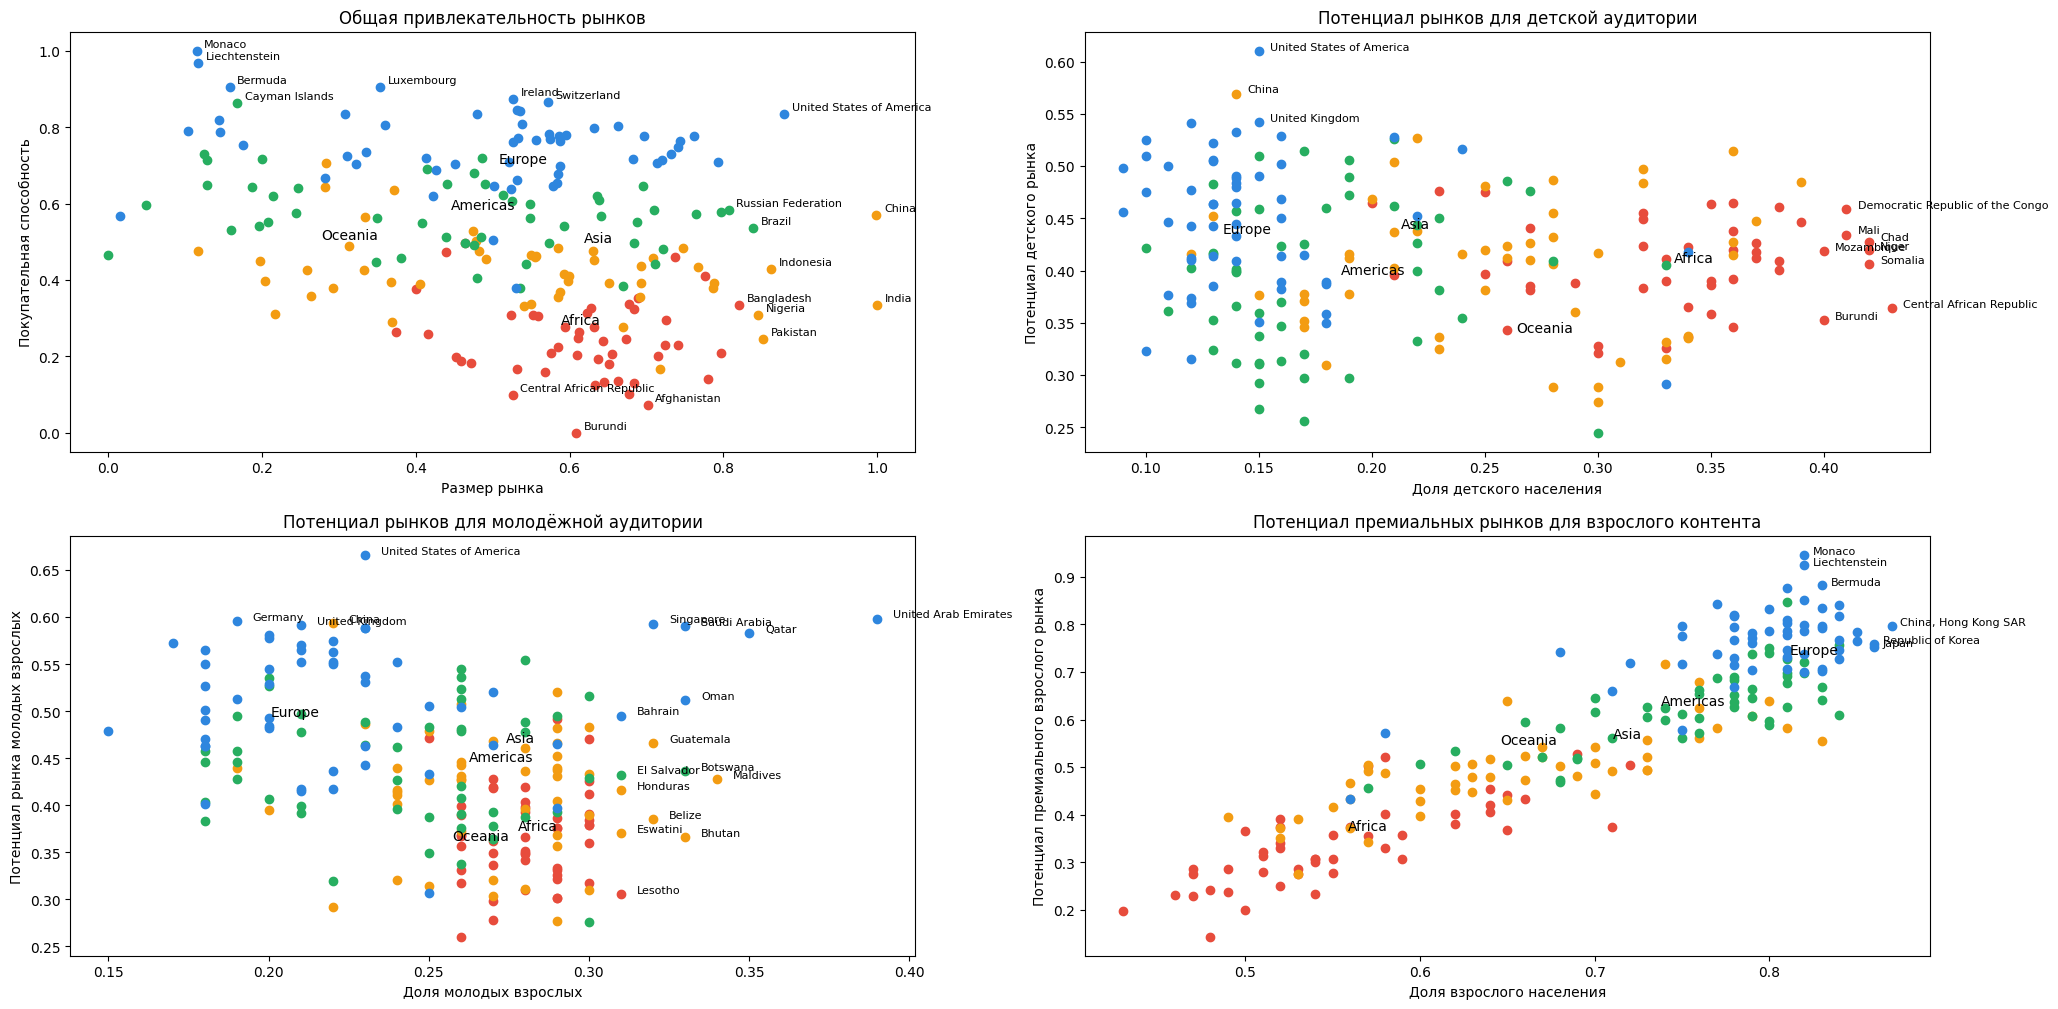

In [254]:
income_colors = {'Low_income': '#E74C3C', 'Lower_middle_income': '#F39C12', 'Upper_middle_income': '#27AE60','High_income': '#2E86DE'}
fig, axes = plt.subplots(2, 2, figsize=(24, 12))

# График 1. Общая привлекательность рынков
ax = axes[0,0]
#делаем итерации по группам стран в рамках income_category и наносим их на график 
for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['population_score'],data['wealth_score'], color=color, label=income_cat)
#считаем среднюю точку по региону (после groupby регион становится индексом, поэтому превращаем его в обычгый столбец)
region_labels = regions.groupby('region').agg({'population_score':'mean','wealth_score':'mean',}).reset_index()
#подписываем регионы на графике
for _, row in region_labels.iterrows():
    ax.text(row['population_score'],row['wealth_score'],row['region'],fontsize=10)
#определяем ключевые рынки, котрые хотим показать на графике   
key_markets = regions[(regions['population_score'] >= 0.8) | (regions['wealth_score'] >= 0.85) | (regions['wealth_score'] <= 0.1)]
#подписываем ключевые рынки на графике
for _, row in key_markets.iterrows():
    ax.text(row['population_score'] + 0.01,row['wealth_score'] + 0.01, row['country'], fontsize=8)

ax.set_title('Общая привлекательность рынков')
ax.set_xlabel('Размер рынка')
ax.set_ylabel('Покупательная способность')

# График 2. Потенциал рынков для детского контента
ax = axes[0,1]
#делаем итерации по группам стран в рамках income_category и наносим их на график 
for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['0-12_%'], data['kids_market_score'],color=color, label=income_cat)
#считаем среднюю точку по региону (после groupby регион становится индексом, поэтому превращаем его в обычгый столбец)
region_labels = regions.groupby('region').agg({'0-12_%':'mean', 'kids_market_score':'mean'}).reset_index()
#подписываем регионы на графике
for _, row in region_labels.iterrows():
    ax.text(row['0-12_%'],row['kids_market_score'],row['region'],fontsize=10)
#определяем ключевые рынки, котрые хотим показать на графике   
key_markets = regions[(regions['kids_market_score'] >= regions['kids_market_score'].quantile(0.99)) |
                    (regions['0-12_%'] >= regions['0-12_%'].quantile(0.97))]
#подписываем ключевые рынки на графике
for _, row in key_markets.iterrows():
    ax.text(row['0-12_%'] + 0.005, row['kids_market_score'] + 0.001, row['country'], fontsize=8)

ax.set_title('Потенциал рынков для детской аудитории')
ax.set_xlabel('Доля детского населения')
ax.set_ylabel('Потенциал детского рынка')

# График 3. Потенциал рынков для молодежной аудитории
ax = axes[1,0]
#делаем итерации по группам стран в рамках income_category и наносим их на график 
for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['young_adults_%'], data['youth_market_score'],color=color, label=income_cat)
#считаем среднюю точку по региону (после groupby регион становится индексом, поэтому превращаем его в обычгый столбец)
region_labels = regions.groupby('region').agg({'young_adults_%':'mean', 'youth_market_score':'mean'}).reset_index()
#подписываем регионы на графике
for _, row in region_labels.iterrows():
    ax.text(row['young_adults_%'],row['youth_market_score'],row['region'],fontsize=10)
#определяем ключевые рынки, котрые хотим показать на графике   
key_markets = regions[(regions['youth_market_score'] >= regions['youth_market_score'].quantile(0.97)) |
                    (regions['young_adults_%'] >= regions['young_adults_%'].quantile(0.95))]
#подписываем ключевые рынки на графике
for _, row in key_markets.iterrows():
    ax.text(row['young_adults_%'] + 0.005, row['youth_market_score'] + 0.001, row['country'], fontsize=8)

ax.set_title('Потенциал рынков для молодёжной аудитории')
ax.set_xlabel('Доля молодых взрослых')
ax.set_ylabel('Потенциал рынка молодых взрослых')

# График 4. Потенциал премиальных рынков для взрослого контента
ax = axes[1,1]
#делаем итерации по группам стран в рамках income_category и наносим их на график 
for income_cat, color in income_colors.items():
    data = regions[regions['income_category'] == income_cat]
    ax.scatter(data['18+_%'], data['adult_premium_score'],color=color, label=income_cat)
#считаем среднюю точку по региону (после groupby регион становится индексом, поэтому превращаем его в обычгый столбец)
region_labels = regions.groupby('region').agg({'18+_%':'mean', 'adult_premium_score':'mean'}).reset_index()
#подписываем регионы на графике
for _, row in region_labels.iterrows():
    ax.text(row['18+_%'],row['adult_premium_score'],row['region'],fontsize=10)
#определяем ключевые рынки, котрые хотим показать на графике   
key_markets = regions[(regions['adult_premium_score'] >= regions['adult_premium_score'].quantile(0.99)) |
                    (regions['18+_%'] >= regions['18+_%'].quantile(0.99))]
#подписываем ключевые рынки на графике
for _, row in key_markets.iterrows():
    ax.text(row['18+_%'] + 0.005, row['adult_premium_score'] + 0.001, row['country'], fontsize=8)

ax.set_title('Потенциал премиальных рынков для взрослого контента')
ax.set_xlabel('Доля взрослого населения')
ax.set_ylabel('Потенциал премиального взрослого рынка')

#### Матрица общей привлекательности рынков
Матрица демонстрирует различия рынков по уровню покупательной способности и масштабу аудитории. Развитые рынки Северной Америки и Западной Европы характеризуются высоким уровнем доходов и значительным коммерческим потенциалом, тогда как крупнейшие развивающиеся рынки Азии обладают существенно более масштабной аудиторией. Небольшие обеспеченные экономики формируют премиальные нишевые рынки с высокой покупательной способностью, но ограниченным потенциалом массового охвата.
#### Матрица потенциала детского рынка
Наибольший потенциал для детского и семейного контента сосредоточен в крупных демографически молодых странах Азии, Латинской Америки и части Африки. Индия, Китай, Индонезия и Бразилия сочетают высокую долю детского населения с масштабной потребительской базой, что делает их особенно привлекательными для лицензирования, производства товаров и развития семейных развлекательных брендов.
#### Матрица потенциала молодёжного рынка
Контент, ориентированный на молодую аудиторию, демонстрирует наиболее высокий потенциал в странах Азии и Ближнего Востока. США, Китай, Индия, Саудовская Аравия и ОАЭ сочетают высокую долю молодой аудитории с масштабируемой развлекательной инфраструктурой, что делает их наиболее перспективными для крупных франшиз, игровых экосистем и проектов, основанных на фанатских сообществах.
#### Матрица потенциала взрослого премиального рынка
Наибольший потенциал для премиального и взрослого контента сосредоточен в развитых странах Европы и Северной Америки с высоким уровнем доходов населения. Высокая покупательная способность и зрелая структура аудитории делают такие рынки наиболее привлекательными для премиальных стриминговых сервисов, коллекционного лицензирования и партнерств в сегменте премиального развлечения.


#### Классифицирование рынков
Выполняем классификацию международных рынков развлекательного контента на:
 - Премиальные зрелые рынки - развитые страны с высоким уровнем доходов и покупательной способность
 - Рынки масштабируемого роста - крупные растущие рынки с высокой концентрацией молодой аудитории
 - Рынки с ограниченным коммерческим потенциалом - рынки с низким потенциалом масштабирования и монетизации

In [255]:
regions['premium_market_score'] = regions['adult_premium_score']
regions['growth_market_score'] = (0.4 * regions['youth_market_score'] + 0.35 * regions['kids_market_score'] + 0.25 * regions['wealth_score'])

#Порог 0.58 для growth подбирала вручную, при 0.60 слишком много стран падало в Limited
conditions = [regions['premium_market_score'] >= 0.8,  regions['growth_market_score'] >= 0.45]

choices = ['Premium Mature Markets','Scalable Growth Markets']

regions['market_archetype_final'] = np.select(conditions,choices,default='Limited Commercial Potential')

market_archetypes = (regions[['country','region', 'income_category', '0-12_%','young_adults_%','18+_%','population_score', 'wealth_score', 'kids_market_score', 'youth_market_score', 
                                    'adult_premium_score', 'growth_market_score', 'premium_market_score','market_archetype_final']].sort_values(['market_archetype_final', 'growth_market_score', 'premium_market_score'],
                                    ascending=[True, False, False]))

market_archetypes.head(2)

,country,region,income_category,0-12_%,young_adults_%,18+_%,population_score,wealth_score,kids_market_score,youth_market_score,adult_premium_score,growth_market_score,premium_market_score,market_archetype_final
229,French Polynesia,Oceania,Lower_middle_income,0.17,0.24,0.76,0.281182,0.644421,0.351240,0.414123,0.679094,0.449688,0.679094,Limited Commercial Potential
184,Turks and Caicos Islands,Americas,Upper_middle_income,0.15,0.24,0.80,0.128499,0.714429,0.311803,0.396321,0.740100,0.446267,0.740100,Limited Commercial Potential


### Часть 4. Анализ соответствия контента и рынков 
Объединяем характеристики контента и характеристики рынков в единую таблицу, чтобы оценить, насколько каждый фильм или сериал подходит каждому рынку.

Мы не соединяем реальные события. У content/фильма нет “страны” как ключа. Мы создаем все возможные пары (фильм × рынок), чтобы потом посчитать fit score, насколько аудитория фильма совпадает с характеристиками рынка.


In [256]:
content['key'] = 1
market_archetypes['key'] = 1
content = content[['title','rating','user rating size','audience_segment','kids_audience_fit','youth_audience_fit','adult_audience_fit', 'key']]
markets = market_archetypes[['country','region','income_category','wealth_score','kids_market_score','youth_market_score','adult_premium_score','market_archetype_final','key']]
content_market_fit = (pd.merge(content, market_archetypes, on='key', how='outer').drop('key', axis=1))
content_market_fit.head(2)

,title,rating,user rating size,audience_segment,kids_audience_fit,youth_audience_fit,adult_audience_fit,country,region,income_category,...,young_adults_%,18+_%,population_score,wealth_score,kids_market_score,youth_market_score,adult_premium_score,growth_market_score,premium_market_score,market_archetype_final
0,White Chicks,PG-13,80,Teens,0.2,1.0,0.6,French Polynesia,Oceania,Lower_middle_income,...,0.24,0.76,0.281182,0.644421,0.351240,0.414123,0.679094,0.449688,0.679094,Limited Commercial Potential
1,White Chicks,PG-13,80,Teens,0.2,1.0,0.6,Turks and Caicos Islands,Americas,Upper_middle_income,...,0.24,0.80,0.128499,0.714429,0.311803,0.396321,0.740100,0.446267,0.740100,Limited Commercial Potential


Определяем Fit Score для каждой пары 'контент–рынок'. Коэффициенты заданы вручную для целей проекта. Мы предполагаем, что молодёжный сегмент имеет немного больший вес, потому что он чаще формирует массовый охват, фанатские сообщества и долгосрочный рост. Детский и взрослый сегменты имеют равный вес, так как оба важны для монетизации, но через разные механики. 

In [257]:
content_market_fit['kids_fit'] = (content_market_fit['kids_audience_fit'] *content_market_fit['kids_market_score'])
content_market_fit['youth_fit'] = (content_market_fit['youth_audience_fit'] * content_market_fit['youth_market_score'])
content_market_fit['adult_fit'] = (content_market_fit['adult_audience_fit'] * content_market_fit['adult_premium_score'])


content_market_fit['commercial_fit'] = (0.3 * content_market_fit['kids_fit'] + 0.4 * content_market_fit['youth_fit'] + 0.3 * content_market_fit['adult_fit'])

result = (content_market_fit[['title','rating','audience_segment', 'user rating size','country','region','income_category','market_archetype_final',
                              'kids_fit','youth_fit','adult_fit','commercial_fit']].sort_values('commercial_fit', ascending=False))

result.head(2)

,title,rating,audience_segment,user rating size,country,region,income_category,market_archetype_final,kids_fit,youth_fit,adult_fit,commercial_fit
49958,Gotham,TV-14,Teens,80,United States of America,Americas,High_income,Premium Mature Markets,0.122068,0.666235,0.490515,0.450269
45335,The Returned,TV-14,Teens,82,United States of America,Americas,High_income,Premium Mature Markets,0.122068,0.666235,0.490515,0.450269


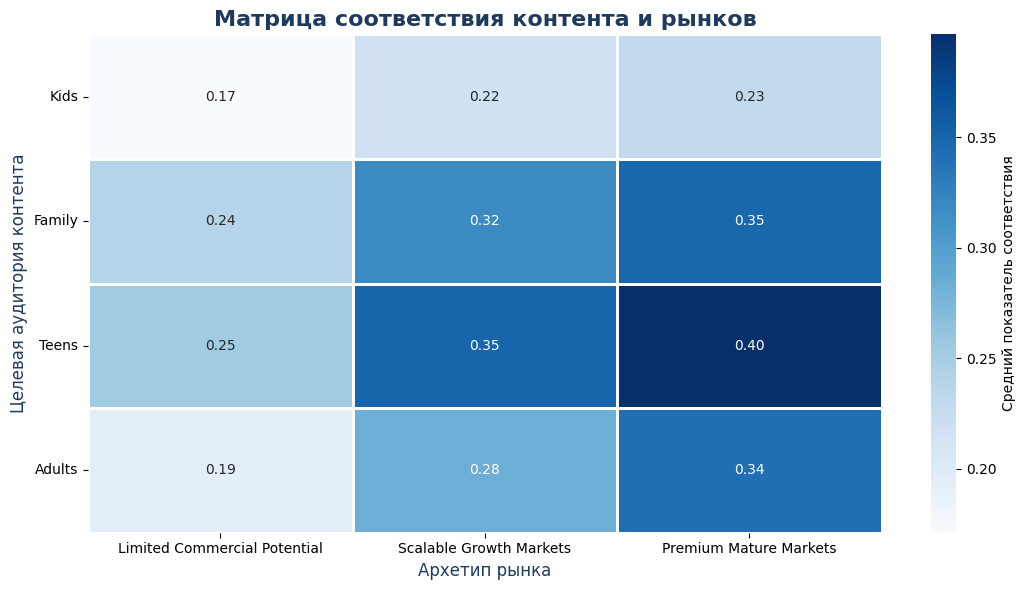

In [258]:
#строим Матрицу соответствия контента и рынков
fit_matrix = (result.groupby(['audience_segment', 'market_archetype_final'], as_index=False).agg(avg_commercial_fit=('commercial_fit', 'mean')))
fit_pivot = fit_matrix.pivot(index='audience_segment',columns='market_archetype_final',values='avg_commercial_fit')

audience_order = ['Kids', 'Family', 'Teens', 'Adults']
market_order = ['Limited Commercial Potential','Scalable Growth Markets','Premium Mature Markets']

fit_pivot = fit_pivot.reindex(index=audience_order,columns=market_order)

plt.figure(figsize=(11, 6))

sns.heatmap(fit_pivot,annot=True,cmap='Blues',linewidths=1,fmt='.2f',cbar_kws={'label': 'Средний показатель соответствия'})
plt.title('Матрица соответствия контента и рынков', fontsize=16,fontweight='bold',color='#1f3a5f')
plt.xlabel('Архетип рынка', fontsize=12, color='#1f3a5f')
plt.ylabel('Целевая аудитория контента', fontsize=12, color='#1f3a5f')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Построенный фреймворк Content-Market Fit позволил определить, какие типы контента обладают наибольшим потенциалом на различных ранках. Проведённый анализ показывает, что коммерческий потенциал контента зависит не только от качества самого контента, но и от соответствия демографическим и экономическим характеристикам рынка.

**Детский контент / Kids Content** показывает более низкий коммерческий потенциал, поскольку значительная часть детского потребления происходит в рамках семейного контента. Наиболее перспективными для данного сегмента остаются растущие и развитые рынки.

**Семейный контент/Family Content** показывает высокую универсальность и способен успешно масштабироваться как на растущих, так и на развитых рынках. Данный сегмент обладает дополнительным потенциалом монетизации через лицензирование, мерчендайзинг и развитие развлекательных экосистем.

**Подростковый контент/Teen Content** демонстрирует наивысший коммерческий потенциал практически на всех типах рынков. Наибольшее соответствие наблюдается на рынках масштабируемого роста, где высокая концентрация молодой аудитории создаёт благоприятные условия для развития франшиз, игровых экосистем, стриминговых сервисов и контента, основанного на фанатских сообществах.

**Взрослая аудитория/Adult Content** наиболее эффективен на премиальных зрелых рынках с высокой покупательскоой способностью населения. Такие рынки обеспечивают максимальный потенциал подписочной монетизации и потребления премиального контента.

Разработанный фреймворк Content-Market Fit показывает, что успешная международная стратегия Netflix должна учитывать не только популярность контента, но и соответствие возрастной структуре аудитории, масштаба рынка и уровня покупательской способности населения. Результаты анализа позволяют определить, какой тип контента обладает наибольшим коммерческим потенциалом на каждом типе международного рынка и где вероятность успешного масштабирования контента наиболее высока.